In [2]:
# Standard library
import os            # File paths, environment
import tempfile      # Temporary files
import zipfile       # Extracting ZIP archives

# Data & geospatial
import numpy as np
import pandas as pd
import geopandas as gpd

# Plotting
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

# Statistics
import statsmodels.api as sm
from scipy import stats
from scipy.stats import pearsonr

# Networking
import requests

In [3]:
msoa_uk = gpd.read_file(r"D:\OneDrive\Imago-training\data\UK_MSOA_IZB_SDZ.shp")

In [4]:
msoa_uk.head()

,dt_zn_c,dt_zn_n,country,MSOA21C,MSOA21N,DZ21C,DZ21N,IZCode,IZName,geometry
0,E02000001,City of London 001,england_wales,E02000001,City of London 001,None,None,None,None,"POLYGON ((532135.138 182198.131, 532158.25 182..."
1,E02000002,Barking and Dagenham 001,england_wales,E02000002,Barking and Dagenham 001,None,None,None,None,"POLYGON ((548881.563 190845.265, 548881.125 19..."
2,E02000003,Barking and Dagenham 002,england_wales,E02000003,Barking and Dagenham 002,None,None,None,None,"POLYGON ((549102.438 189324.625, 548954.517 18..."
3,E02000004,Barking and Dagenham 003,england_wales,E02000004,Barking and Dagenham 003,None,None,None,None,"POLYGON ((551550.056 187364.705, 551478 187263..."
4,E02000005,Barking and Dagenham 004,england_wales,E02000005,Barking and Dagenham 004,None,None,None,None,"POLYGON ((549099.634 187656.076, 549161.375 18..."


In [5]:
temp = pd.read_csv(r"D:\OneDrive\Imago-training\data\temperature_indicators_MSOA_2023.csv")

In [6]:
msoa_uk.rename(columns = {'dt_zn_c':'data_zone_code'}, inplace = True)

In [7]:
msoa_temp = msoa_uk.merge(temp, on="data_zone_code", how="left")

In [8]:
temp["summer_max_tmp"].describe()

count    9448.000000
mean       22.416064
std         1.529190
min        14.995362
25%        21.516840
50%        22.557136
75%        23.472169
max        25.182354
Name: summer_max_tmp, dtype: float64

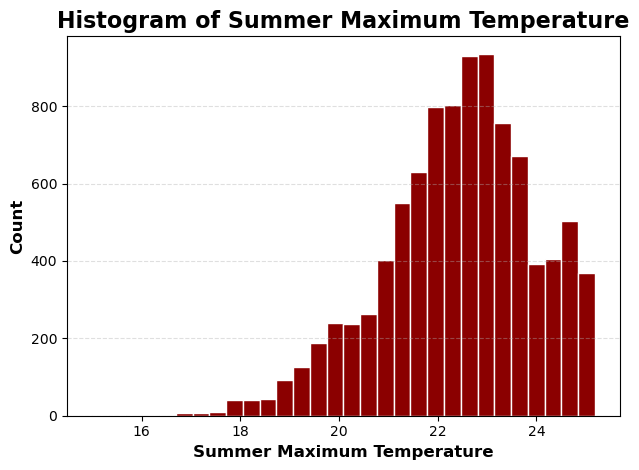

In [9]:
fig, ax = plt.subplots()

ax.hist(
    msoa_temp["summer_max_tmp"],
    bins=30,
    edgecolor="white",
    color="darkred"
)

# Labels and title
ax.set_title("Histogram of Summer Maximum Temperature", fontsize=16, fontweight="bold", loc="center")
ax.set_xlabel("Summer Maximum Temperature", fontsize=12, fontweight="bold")
ax.set_ylabel("Count", fontsize=12, fontweight="bold")

# Minimal-style adjustments
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.grid(axis="x", visible=False)
ax.set_facecolor("white")
fig.set_facecolor("white")

plt.tight_layout()
plt.show()

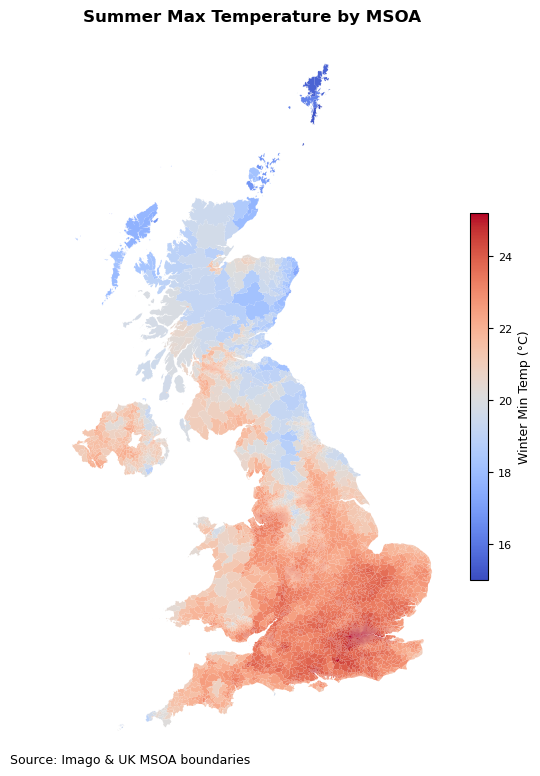

In [10]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Colormap 
viridis = plt.get_cmap('coolwarm')

# Plot MSOA polygons coloured by winter minimum temperature
msoa_temp.plot(
    column="summer_max_tmp",
    cmap=viridis,
    linewidth=0,
    legend=True,
    legend_kwds={
        "shrink": 0.5,        # shrink colorbar
        "aspect": 20,         # controls thickness
        "pad": 0.02,          # spacing from plot
        "label": "Summer Max Temp (°C)",
    },
    ax=ax
)

# Title and labels
ax.set_title(
    "Summer Max Temperature by MSOA",
    fontsize=12,
    fontweight="bold"
)
ax.set_axis_off()

# Make legend text smaller after creation
cb = ax.get_figure().axes[-1]   # colorbar axis is always last
cb.tick_params(labelsize=8)     # smaller tick labels
cb.set_ylabel("Winter Min Temp (°C)", fontsize=9)

plt.figtext(
    0.5, 0.02,
    "Source: Imago & UK MSOA boundaries",
    ha="center",
    fontsize=9
)

plt.tight_layout()
plt.show()

In [11]:
# Create a temporary file with .xlsx extension
tmp_file = tempfile.NamedTemporaryFile(delete=False, suffix=".xlsx").name

# Download
url = "https://assets.publishing.service.gov.uk/media/691decfae39a085bda43efcd/File_2_IoD2025_Domains_of_Deprivation.xlsx"
r = requests.get(url)
with open(tmp_file, "wb") as f:
    f.write(r.content)

# Read Excel sheet & Clean up temp file
imd = pd.read_excel(tmp_file, sheet_name="IoD2025 Domains")
os.remove(tmp_file)

# Now imd exists
print(imd.columns.tolist())

['LSOA code (2021)', 'LSOA name (2021)', 'Local Authority District code (2024)', 'Local Authority District name (2024)', 'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)', 'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)', 'Income Rank (where 1 is most deprived)', 'Income Decile (where 1 is most deprived 10% of LSOAs)', 'Employment Rank (where 1 is most deprived)', 'Employment Decile (where 1 is most deprived 10% of LSOAs)', 'Education, Skills and Training Rank (where 1 is most deprived)', 'Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)', 'Health Deprivation and Disability Rank (where 1 is most deprived)', 'Health Deprivation and Disability Decile (where 1 is most deprived 10% of LSOAs)', 'Crime Rank (where 1 is most deprived)', 'Crime Decile (where 1 is most deprived 10% of LSOAs)', 'Barriers to Housing and Services Rank (where 1 is most deprived)', 'Barriers to Housing and Services Decile (where 1 i

In [12]:
imd.shape

(33755, 20)

In [13]:
# Create temporary paths
zip_file = tempfile.NamedTemporaryFile(delete=False, suffix=".zip").name
unzipped_dir = tempfile.mkdtemp()

# Download ZIP
url = "https://www.arcgis.com/sharing/rest/content/items/7fc55d71a09d4dcfa1fd6473138aacc3/data"
r = requests.get(url)

with open(zip_file, "wb") as f:
    f.write(r.content)

# Unzip
with zipfile.ZipFile(zip_file, "r") as z:
    z.extractall(unzipped_dir)

# Delete ZIP immediately
os.remove(zip_file)

# Locate lookup CSV
lookup_path = None
for root, dirs, files in os.walk(unzipped_dir):
    for file in files:
        if file.lower().endswith(".csv"):
            lookup_path = os.path.join(root, file)
            break
    if lookup_path:
        break

if lookup_path is None:
    raise FileNotFoundError("No CSV found in the downloaded ZIP.")

# Load lookup table
LSOA21_MSOA21 = pd.read_csv(lookup_path)

# Keep only necessary columns
LSOA21_MSOA21 = LSOA21_MSOA21[
    ["lsoa21cd", "msoa21cd", "ladcd", "lsoa21nm", "msoa21nm", "ladnm"]
]

# Drop any duplicates just in case
LSOA21_MSOA21.drop_duplicates(subset=["lsoa21cd"], inplace=True, keep="first")


# Join to IMD
lsoa_msoa_imd = LSOA21_MSOA21.merge(
    imd,
    how="left",
    left_on="lsoa21cd",
    right_on="LSOA code (2021)"

)

C:\Users\spspa\AppData\Local\Temp\ipykernel_10304\2015926661.py:33: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  LSOA21_MSOA21 = pd.read_csv(lookup_path)


In [14]:
# Select the required columns
lsoa_msoa_imd_clean = lsoa_msoa_imd[
    [
        "lsoa21cd",
        "msoa21cd",
        "ladcd",
        "lsoa21nm",
        "msoa21nm",
        "ladnm",
        "Health Deprivation and Disability Rank (where 1 is most deprived)",
        "Health Deprivation and Disability Decile (where 1 is most deprived 10% of LSOAs)"
    ]
].rename(
    columns={
        "Health Deprivation and Disability Rank (where 1 is most deprived)": "health_rank",
        "Health Deprivation and Disability Decile (where 1 is most deprived 10% of LSOAs)": "health_decile"
    }
)

In [15]:
# Compute the percentage of non-missing IMD ranks
pct_non_missing = lsoa_msoa_imd_clean['health_rank'].notna().mean() * 100

print(pct_non_missing)

76.86089669148622


In [16]:
msoa_imd_agg = (
    lsoa_msoa_imd_clean
    .groupby(["msoa21cd", "msoa21nm", "ladcd", "ladnm"], as_index=False)
    .agg(health_rank_msoa=("health_rank", "mean"))  # mean ignores NaN by default
)

# Strip whitespace and ensure string type for MSOA codes

msoa_imd_agg['msoa21cd'] = msoa_imd_agg['msoa21cd'].astype(str).str.strip()
msoa_temp['msoa21cd'] = msoa_temp['MSOA21C'].astype(str).str.strip()

temp_cols = ["msoa21cd", "summer_max_tmp"]

# Left join on 'msoa21cd'
msoa_final = msoa_imd_agg.merge(
    msoa_temp[temp_cols],
    how="left",
    on="msoa21cd"
)

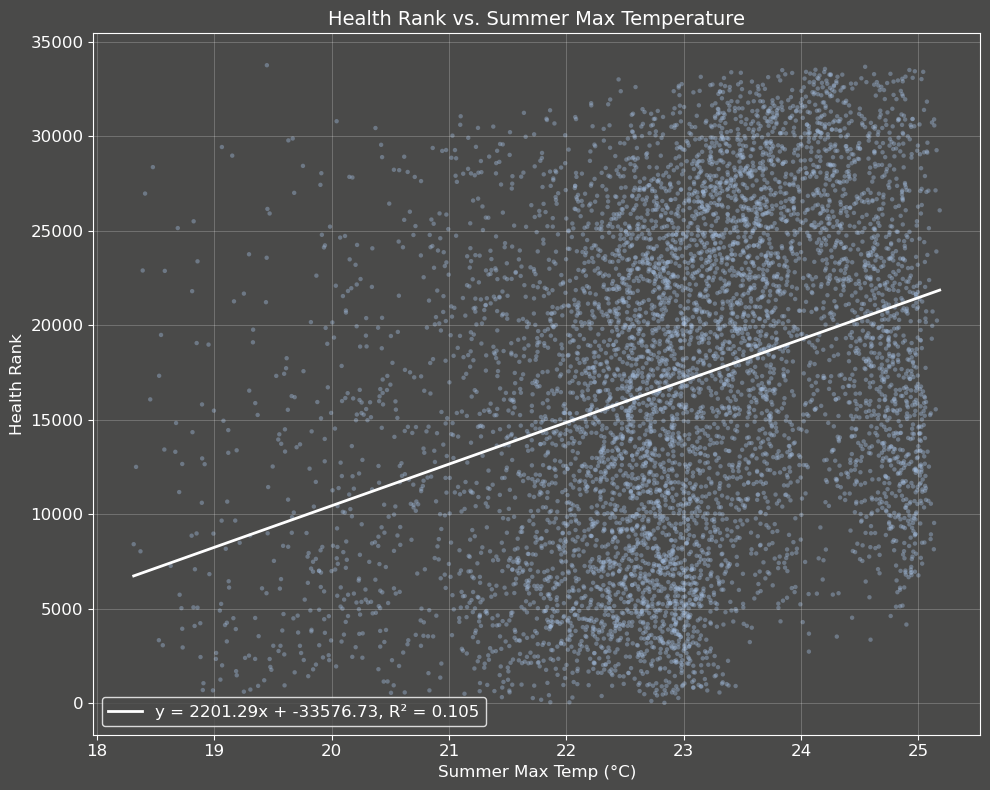

In [17]:
fig, ax = plt.subplots(figsize=(10, 8), facecolor='#4a4a49')
ax.set_facecolor('#4a4a49')

# Extract columns FIRST
x = msoa_final["summer_max_tmp"]
y = msoa_final["health_rank_msoa"]

# Create mask and filter
mask = ~(x.isna() | y.isna())
x = x[mask]
y = y[mask]

# Scatter
ax.scatter(x, y, alpha=0.4, s=10, color='#a4bee0', edgecolor='none')
 
# Regression line
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='white', linewidth=2, label=f'y = {slope:.2f}x + {intercept:.2f}, R² = {r_value**2:.3f}')
 
# Legend
ax.legend(facecolor='#4a4a49', edgecolor='white', labelcolor='white', fontsize=12)
 
# Style
ax.set_xlabel('Summer Max Temp (°C)', color='white', fontsize=12)
ax.set_ylabel('Health Rank', color='white', fontsize=12)
ax.set_title('Health Rank vs. Summer Max Temperature', color='white', fontsize=14)
ax.tick_params(colors='white', labelsize=12)
ax.grid(True, color='white', alpha=0.3, linestyle='-', linewidth=0.5)
for spine in ax.spines.values():
    spine.set_color('white')
 
plt.tight_layout()
plt.show()

In [18]:
print(slope)

2201.292623758129


In [19]:
# Drop rows with missing values
msoa_final_clean = msoa_final.dropna(subset=["health_rank_msoa", "summer_max_tmp"]).copy()

# Create quintiles (1 = most deprived, 5 = least deprived)
msoa_final_clean["health_quintile"] = pd.qcut(
    msoa_final_clean["health_rank_msoa"],
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [20]:
# Merging back to geospatial data
msoa_final_clean = msoa_final_clean.merge(msoa_uk[["data_zone_code","geometry"]], left_on="msoa21cd", right_on="data_zone_code", how="left")

In [21]:
import pandas as pd
import geopandas as gpd

# Create a copy for hotspot analysis
msoa_hotspots = msoa_final_clean.copy()

# Create deciles (5 groups here)
msoa_hotspots["summertemp_decile"] = pd.qcut(
    msoa_hotspots["summer_max_tmp"], q=3, labels=False
) + 1   # labels 1–5
 
msoa_hotspots["health_decile"] = pd.qcut(
    -msoa_hotspots["health_rank_msoa"], q=3, labels=False
) + 1   # labels 1–5, with negative to match R logic
 

# Filter to the hottest temps & most deprived
msoa_hotspots = msoa_hotspots[
    (msoa_hotspots["summertemp_decile"] == 3) &
    (msoa_hotspots["health_decile"] == 3)
]
# Convert to GeoDataFrame (if not already)
msoa_hotspots = gpd.GeoDataFrame(msoa_hotspots, geometry="geometry")


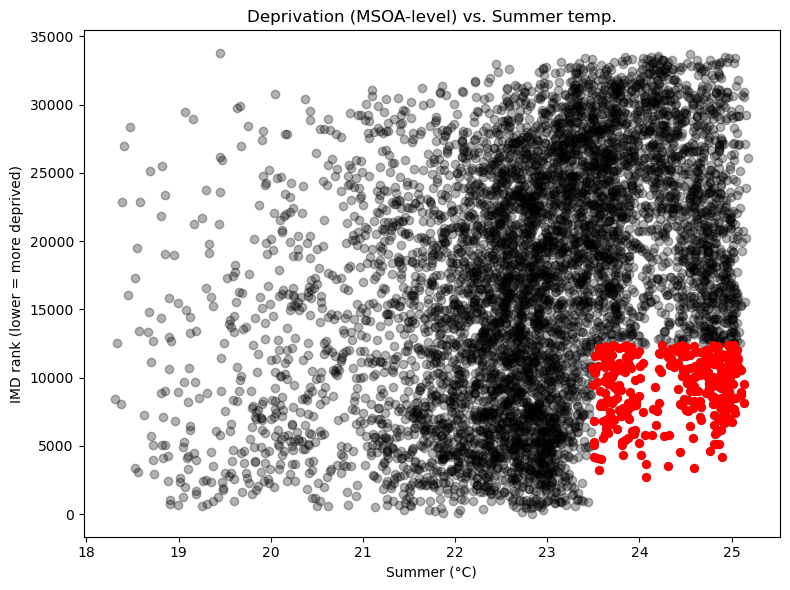

In [22]:
plt.figure(figsize=(8, 6))
 
# All points
plt.scatter(
    msoa_final_clean["summer_max_tmp"],
    msoa_final_clean["health_rank_msoa"],
    color="black",
    alpha=0.3
)
 
# Hotspots (highlighted in red)
plt.scatter(
    msoa_hotspots["summer_max_tmp"],
    msoa_hotspots["health_rank_msoa"],
    color="red",
    s=30
)
 
plt.title("Deprivation (MSOA-level) vs. Summer temp.")
plt.xlabel("Summer (°C)")
plt.ylabel("IMD rank (lower = more deprived)")
 
plt.tight_layout()
plt.show()

C:\Users\spspa\AppData\Local\Temp\ipykernel_10304\1322443298.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


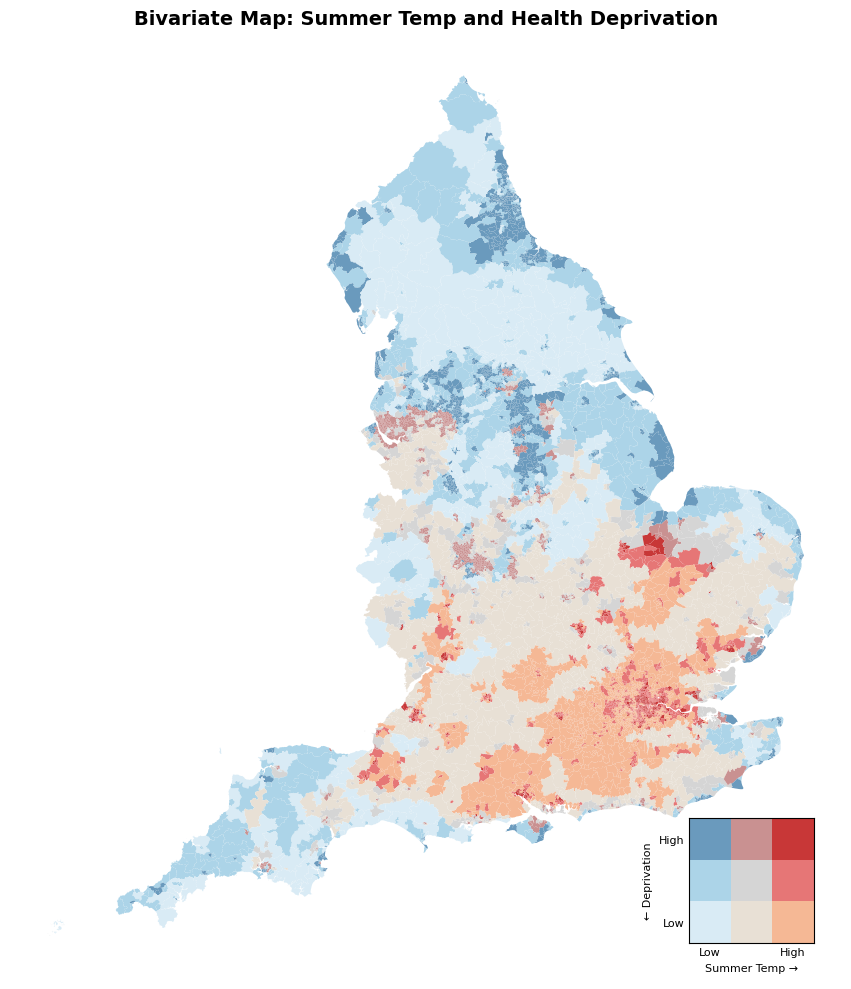

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np

# --- 1. Create bivariate classes ---
# Merging back to geospatial data
msoa_final_clean = msoa_final_clean.merge(msoa_uk[["data_zone_code","geometry"]], left_on="msoa21cd", right_on="data_zone_code", how="left")

msoa_bi = msoa_final_clean.copy()
msoa_bi = gpd.GeoDataFrame(msoa_bi, geometry="geometry")

msoa_bi["summer_class"] = pd.qcut(
    msoa_bi["summer_max_tmp"], 
    q=3, 
    labels=[1, 2, 3]  # 1 = low, 3 = high
)

msoa_bi["health_class"] = pd.qcut(
    msoa_bi["health_rank_msoa"], 
    q=3, 
    labels=[3, 2, 1]  # Reversed: 3 = most deprived (low rank)
)

msoa_bi["bi_class"] = (
    msoa_bi["summer_class"].astype(str) + "-" + msoa_bi["health_class"].astype(str)
)

# --- 2. Define palette ---
bi_palette = {
    "1-1": "#D9EBF5",  # low heat, low deprivation
    "2-1": "#E8E0D5",  # medium heat, low deprivation
    "3-1": "#F5B895",  # high heat, low deprivation
    "1-2": "#ACD4E8",  # low heat, medium deprivation
    "2-2": "#D5D5D5",  # medium heat, medium deprivation
    "3-2": "#E67676",  # high heat, medium deprivation
    "1-3": "#6A9ABD",  # low heat, high deprivation
    "2-3": "#C99191",  # medium heat, high deprivation
    "3-3": "#C83737",  # high heat, high deprivation
}

# Map colors to data
msoa_bi["color"] = msoa_bi["bi_class"].map(bi_palette)

# --- 3. Create map ---
fig, ax = plt.subplots(figsize=(12, 10))

msoa_bi.plot(
    ax=ax,
    color=msoa_bi["color"],
    edgecolor="none"
)

ax.set_title("Bivariate Map: Summer Temp and Health Deprivation", fontweight="bold", fontsize=14)
ax.set_axis_off()

# --- 4. Create inset legend (3x3 grid) ---
ax_legend = inset_axes(
    ax,
    width="15%",
    height="15%",
    loc="lower right",
    borderpad=2
)

# Build legend grid
legend_grid = np.zeros((3, 3), dtype=object)
for i, health in enumerate([3, 2, 1]):      # y-axis: top = most deprived
    for j, summer in enumerate([1, 2, 3]):  # x-axis: left = low temp
        legend_grid[i, j] = bi_palette[f"{summer}-{health}"]

# Convert to RGB for imshow
from matplotlib.colors import to_rgb
rgb_grid = np.array([[to_rgb(c) for c in row] for row in legend_grid])

ax_legend.imshow(rgb_grid, origin="upper")
ax_legend.set_xticks([0, 1, 2])
ax_legend.set_yticks([0, 1, 2])
ax_legend.set_xticklabels(["Low", "", "High"], fontsize=8)
ax_legend.set_yticklabels(["High", "", "Low"], fontsize=8)
ax_legend.set_xlabel("Summer Temp →", fontsize=8)
ax_legend.set_ylabel("← Deprivation", fontsize=8)
ax_legend.tick_params(length=0)

plt.tight_layout()
plt.show()